### **Autor:** David Roca Tauste

---
---
# **📌ACTIVIDAD 2: ÁRBOLES DE DECISIÓN**
---
---

## CLASIFICADORES BASADOS EN ÁRBOLES DE DECISIÓN

a) Define el target y como compra y edad, salario como las predictoras X. Divide en train y test dando un 30% de los datos para test, usando semilla aleatoria formada por la cantidad de letras de tu nombre y apellidos (en mi caso sería 449 porque "Jose" tiene 4 letras, "Rosa" tiene otras 4 letras y "Rodríguez" tiene 9 letras). Intenta que la partición sea homogénea.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("Social_Network_Ads.csv")
X = df[["edad", "salario"]]
y = df["compra"]

semilla = 546
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=semilla, stratify=y
)

b) Crea un clasificador DecisionTreeClassifier llamado clf_1 con random_state a tu semilla. Debes validarlo impriendo la accuracy tanto en el conjunto de entrenamiento como en el de test. Imprime además el informe de clasificación del test. Después crea una figura de 25 de ancho y 20 de alto y dibuja el árbol con plot_tree() indicando class_names y filled=True. Responde a estas preguntas:

Train Accuracy: 0.9964285714285714
Test Accuracy: 0.8583333333333333

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89        77
           1       0.80      0.81      0.80        43

    accuracy                           0.86       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.86      0.86      0.86       120



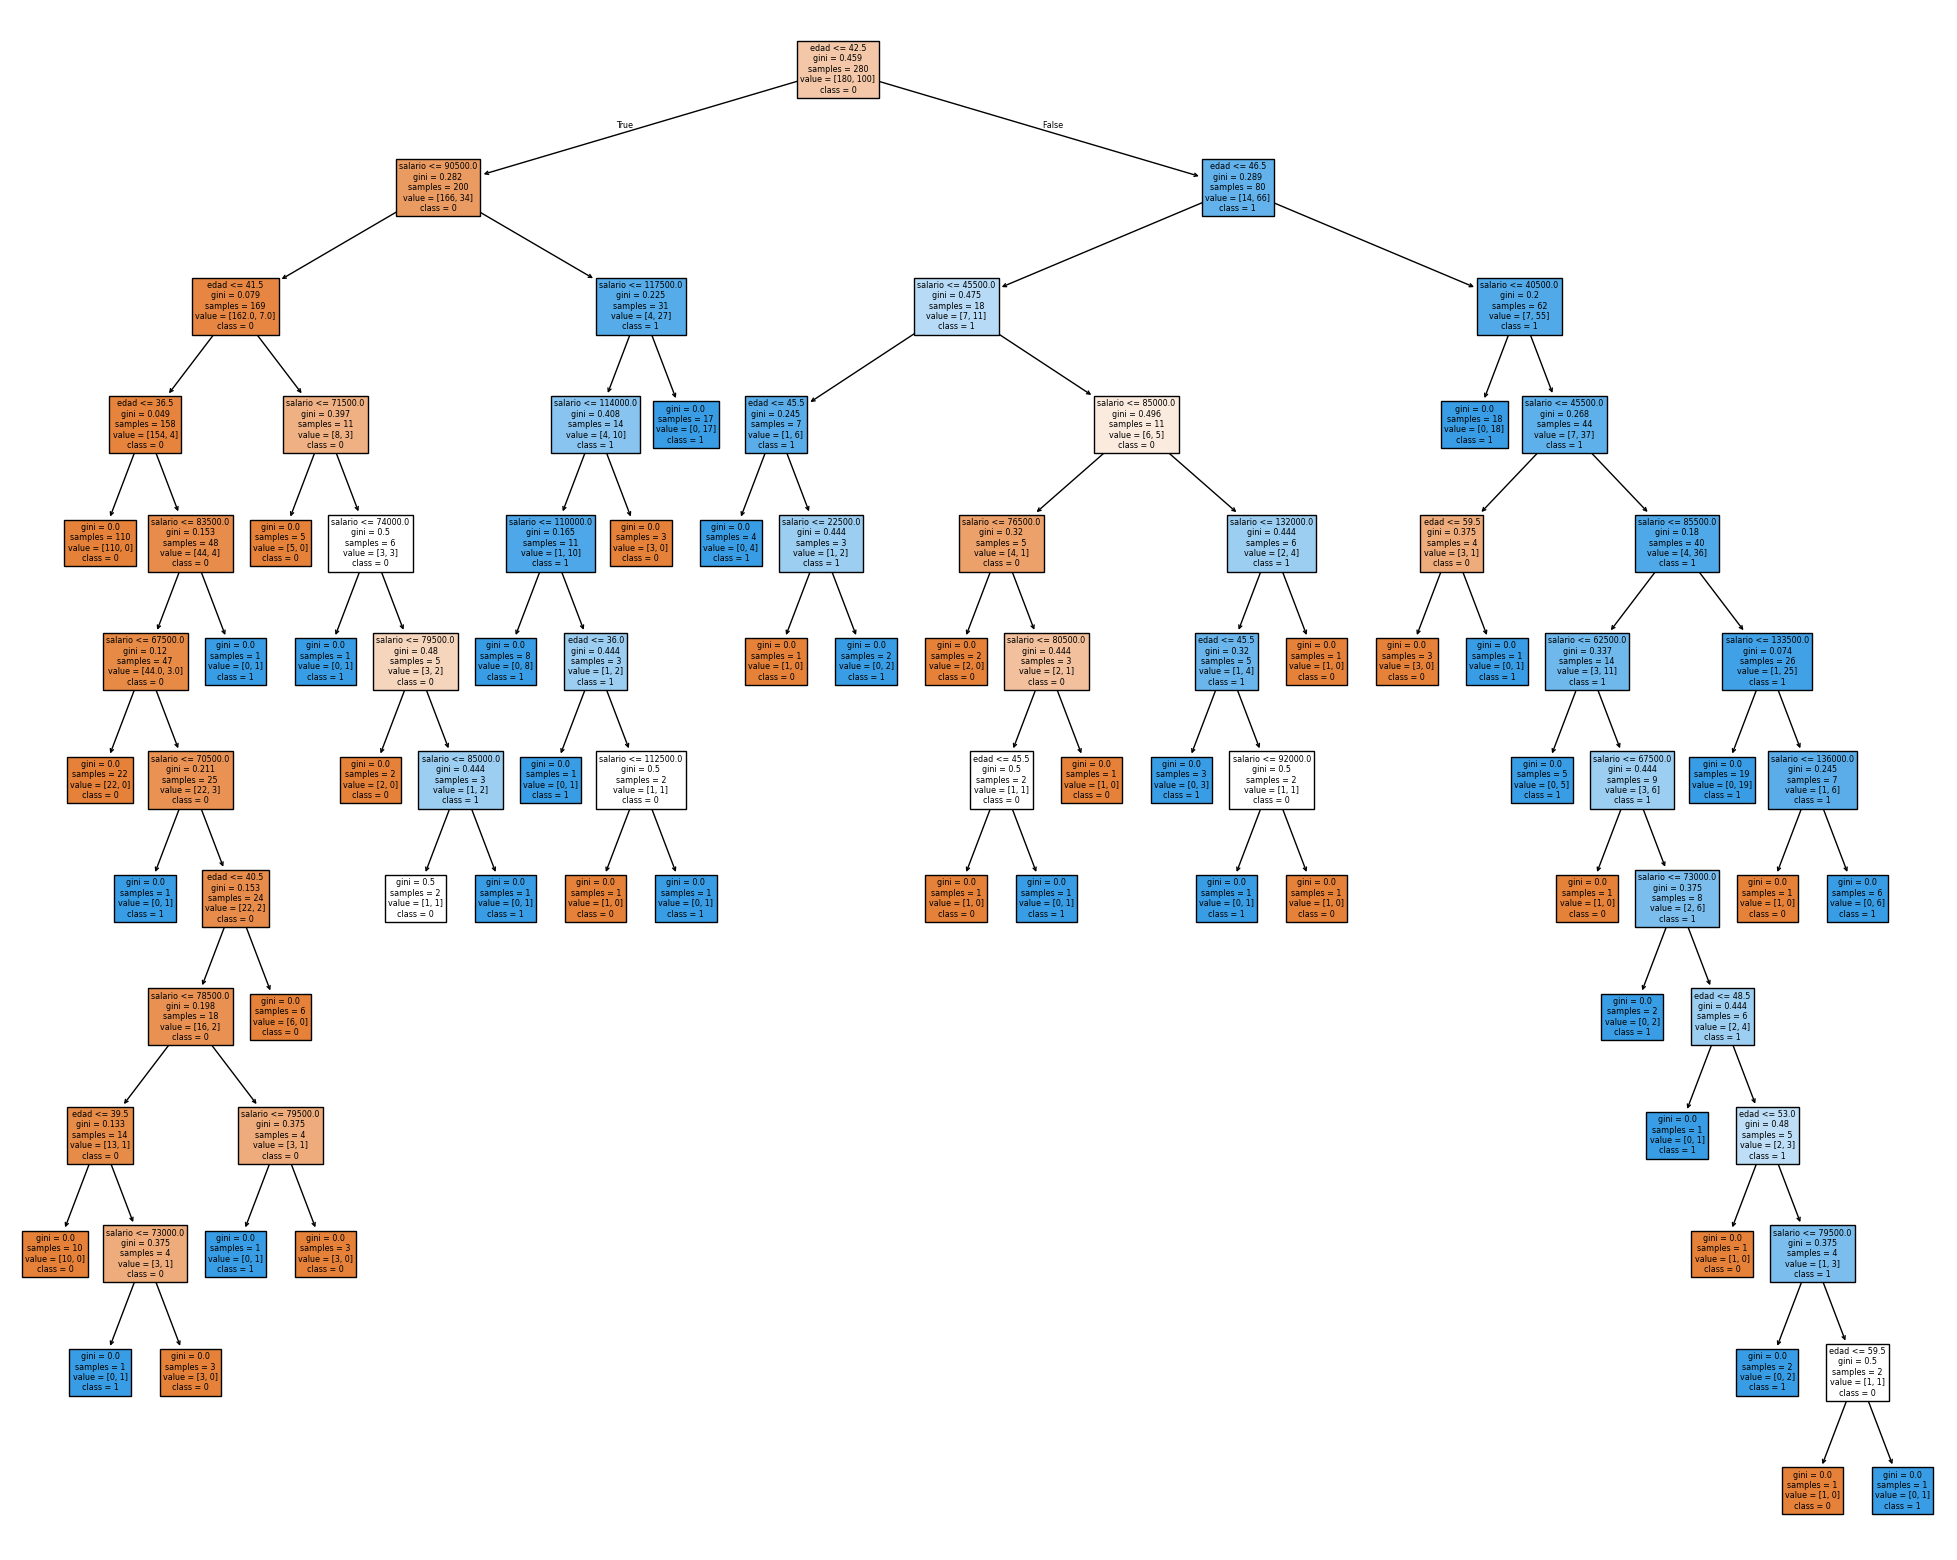

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Modelo
clf_1 = DecisionTreeClassifier(random_state=semilla)
clf_1.fit(X_train, y_train)

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, clf_1.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, clf_1.predict(X_test)))
print(
    "\nReporte de clasificación:\n",
    classification_report(y_test, clf_1.predict(X_test)),
)

# Árbol
plt.figure(figsize=(25, 20))
plot_tree(
    clf_1,
    feature_names=X.columns,
    class_names=[str(c) for c in clf_1.classes_],
    filled=True,
)
plt.show()

- ¿Cuál es el algoritmo o criterio de particionamiento que usa por defecto el árbol?<br>
Por defecto, el árbol utiliza 'gini'.

- ¿Tiene overfitting el modelo que has entrenado?<br>
El modelo tiene una diferencia de accuracy entre train y test del 14%, por lo que sí parece que tenga overfitting. No hay una diferencia descomunal, pero sí notoria.

c) Mira en la unidad y adapta algún código de ejemplo para crear la función frontera_decision_tree(arbol,X,y) que crea una malla de 100x100 puntos (desde el mínimo al máximo de los datos de las dos primeras dimensiones de X) y dibuja la superficie de decisión creada por un árbol previamente entrenado que viene como argumento de la función. Luego sitúa los datos de cada muestra con un color asociado a su clase (el árbol guarda la cantidad de características en arbol.n_classes_ y sus valores en arbol.classes_) en la superficie (cada clase con su propio color. Puedes usar un mapa de colores cargado como cmap=plt.get_cmap("nombre") donde puedes indicar "tab10", "tab20", "hsv", "Set1", "nipy_spectral" que se pueden interpolar: color=cmap(i/arbol.n_classes_).
Luego creas una figura de tamaño (9,11) y haces una llamada pasando el X_test, y_test y aparece una figura similar a la derecha que es el resultado de usar X_train, y_train.

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


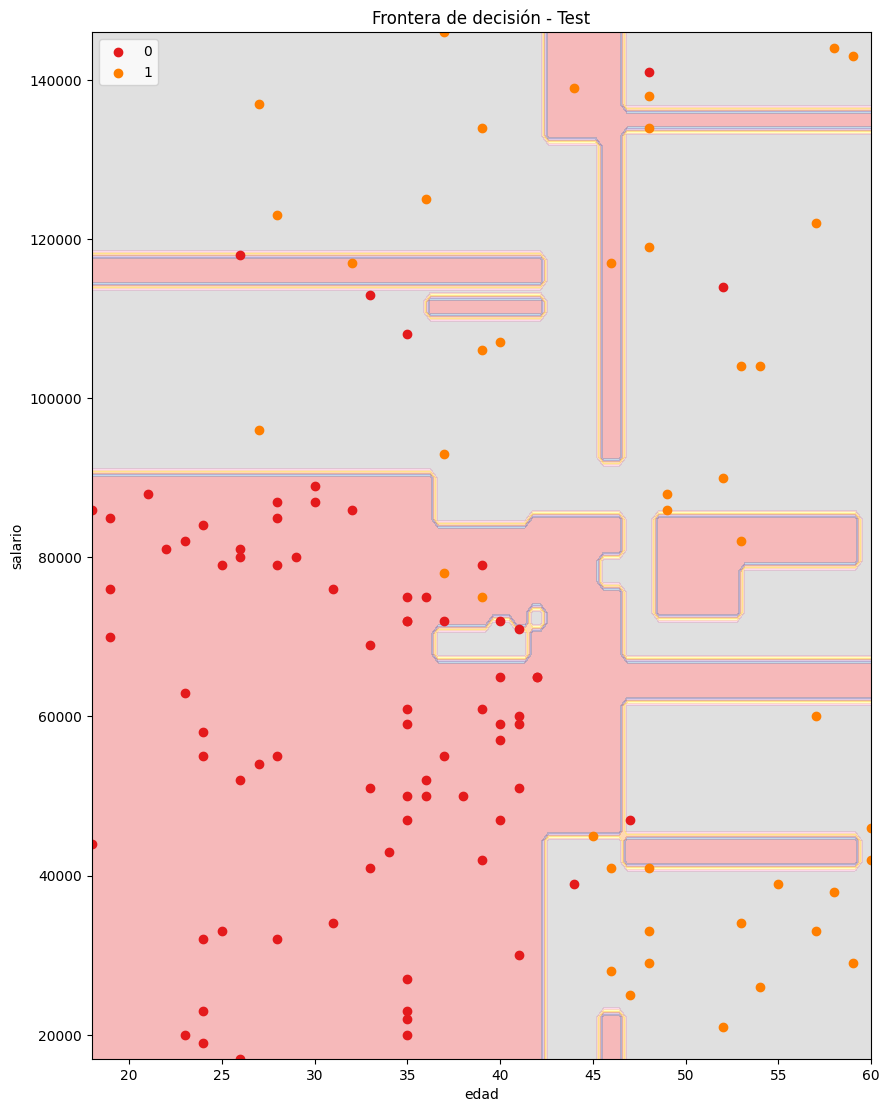

In [3]:
import numpy as np

def frontera_decision_tree(arbol, X, y):
    x_min, x_max = X.iloc[:, 0].min(), X.iloc[:, 0].max()
    y_min, y_max = X.iloc[:, 1].min(), X.iloc[:, 1].max()

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    X_grid = np.c_[xx.ravel(), yy.ravel()]
    Z = arbol.predict(X_grid).reshape(xx.shape)

    cmap = plt.get_cmap("Set1")
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

    for i, valor_clase in enumerate(arbol.classes_):
        idx = y == valor_clase
        plt.scatter(
            X.loc[idx, X.columns[0]],
            X.loc[idx, X.columns[1]],
            label=str(valor_clase),
            color=cmap(i / arbol.n_classes_),
        )

    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.legend()
    plt.tight_layout()


plt.figure(figsize=(9, 11))
frontera_decision_tree(clf_1, X_test, y_test)
plt.title("Frontera de decisión - Test")
plt.show()

d) Crea un nuevo árbol DecisionTreeClassifier llamado clf_2 con random_state a tu semilla y criterio de división 'entropy' y repite las mismas operaciones del apartado b) incluido el dibujo del árbol y el dibujo de la llamada a la frontera de decisión. Responde:

Train Accuracy: 0.9964285714285714
Test Accuracy: 0.8666666666666667

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        77
           1       0.80      0.84      0.82        43

    accuracy                           0.87       120
   macro avg       0.85      0.86      0.86       120
weighted avg       0.87      0.87      0.87       120



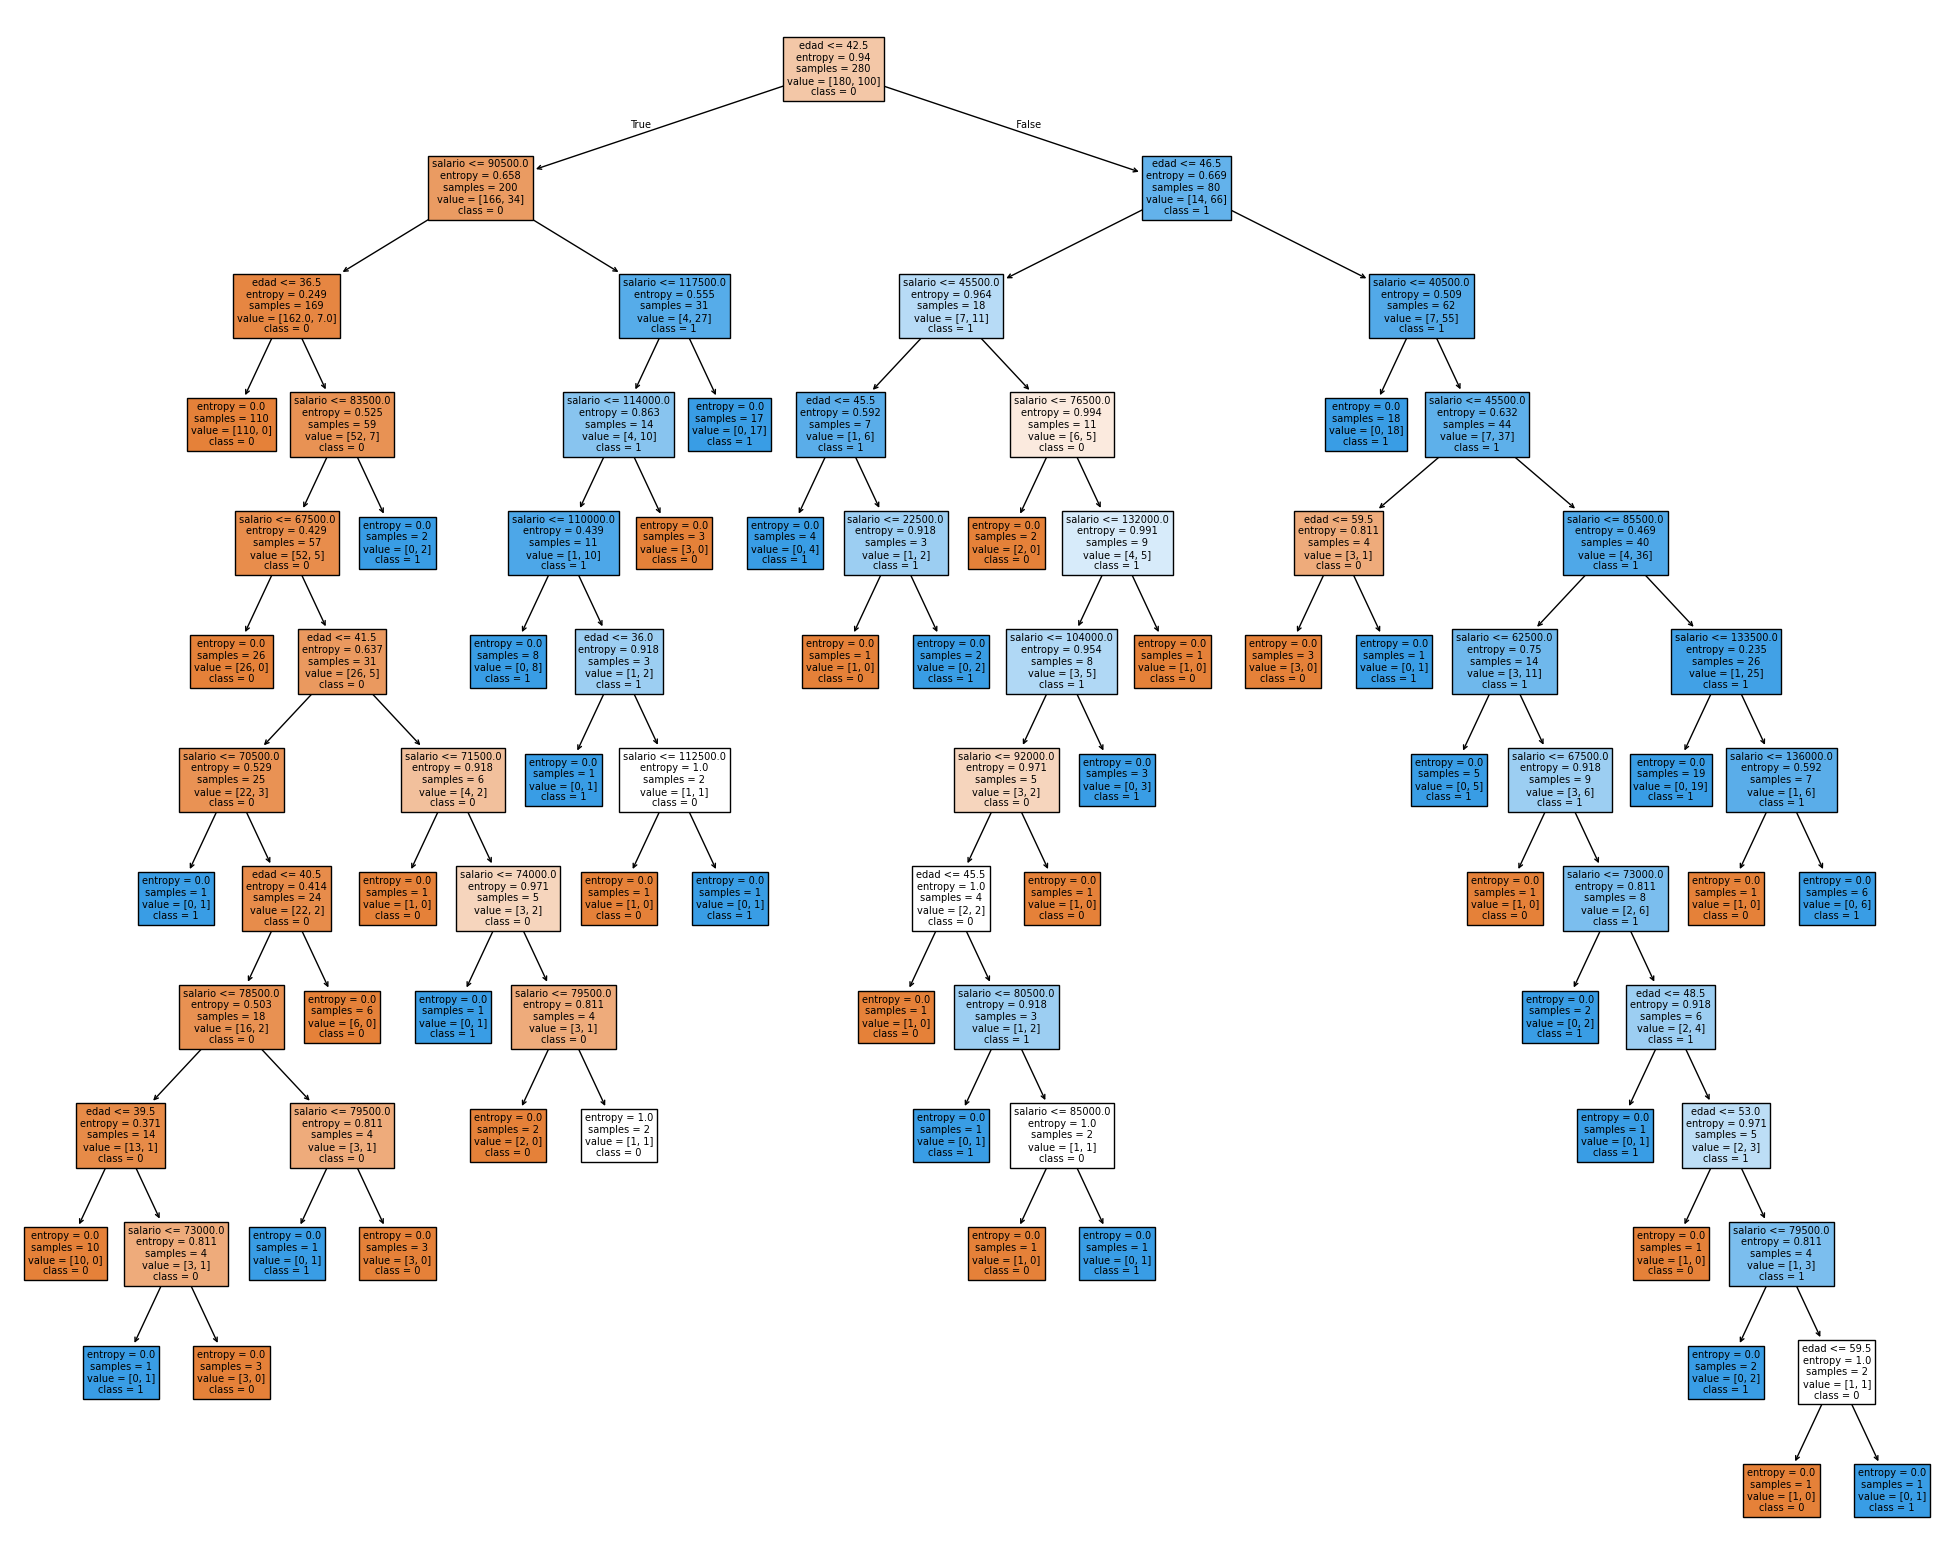

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


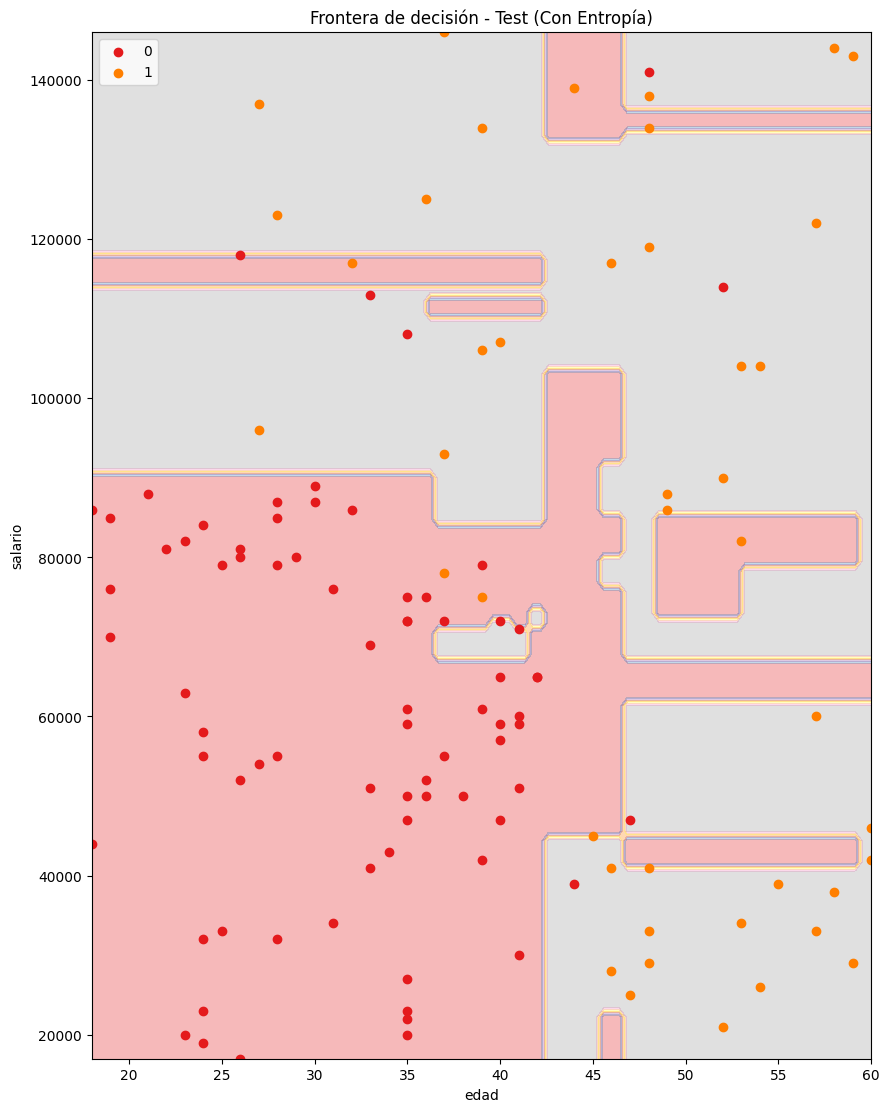

In [4]:
clf_2 = DecisionTreeClassifier(criterion="entropy", random_state=semilla)
clf_2.fit(X_train, y_train)

print("Train Accuracy:", accuracy_score(y_train, clf_2.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, clf_2.predict(X_test)))
print(
    "\nReporte de clasificación:\n",
    classification_report(y_test, clf_2.predict(X_test)),
)

# Árbol
plt.figure(figsize=(25, 20))
plot_tree(
    clf_2,
    feature_names=X.columns,
    class_names=[str(c) for c in clf_2.classes_],
    filled=True,
)
plt.show()

# Frontera de decisión
plt.figure(figsize=(9, 11))
frontera_decision_tree(clf_2, X_test, y_test)
plt.title("Frontera de decisión - Test (Con Entropía)")
plt.show()

- ¿Cambia la estructura del árbol?<br>
Sí que cambia la estructura.

- ¿Cambian las fronteras?<br>
Por lo que yo veo, no cambian.

- Los valores del accuracy sugiere cambios en overfitting/underfitting<br>
La diferencia entre el train y test se ha reducido en un 1% (test ha subido de 0'85 a 0'86), por lo que se podría decir que se ha disminuido un poco el overfitting.

e) Crea un nuevo árbol DecisionTreeClassifier llamado clf_3 con random_state a tu semilla y criterio de división 'log_loss' y repite las mismas operaciones del apartado b) incluido el dibujo del árbol y el dibujo de la llamada a la frontera de decisión.

Train Accuracy: 0.9964285714285714
Test Accuracy: 0.8666666666666667

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        77
           1       0.80      0.84      0.82        43

    accuracy                           0.87       120
   macro avg       0.85      0.86      0.86       120
weighted avg       0.87      0.87      0.87       120



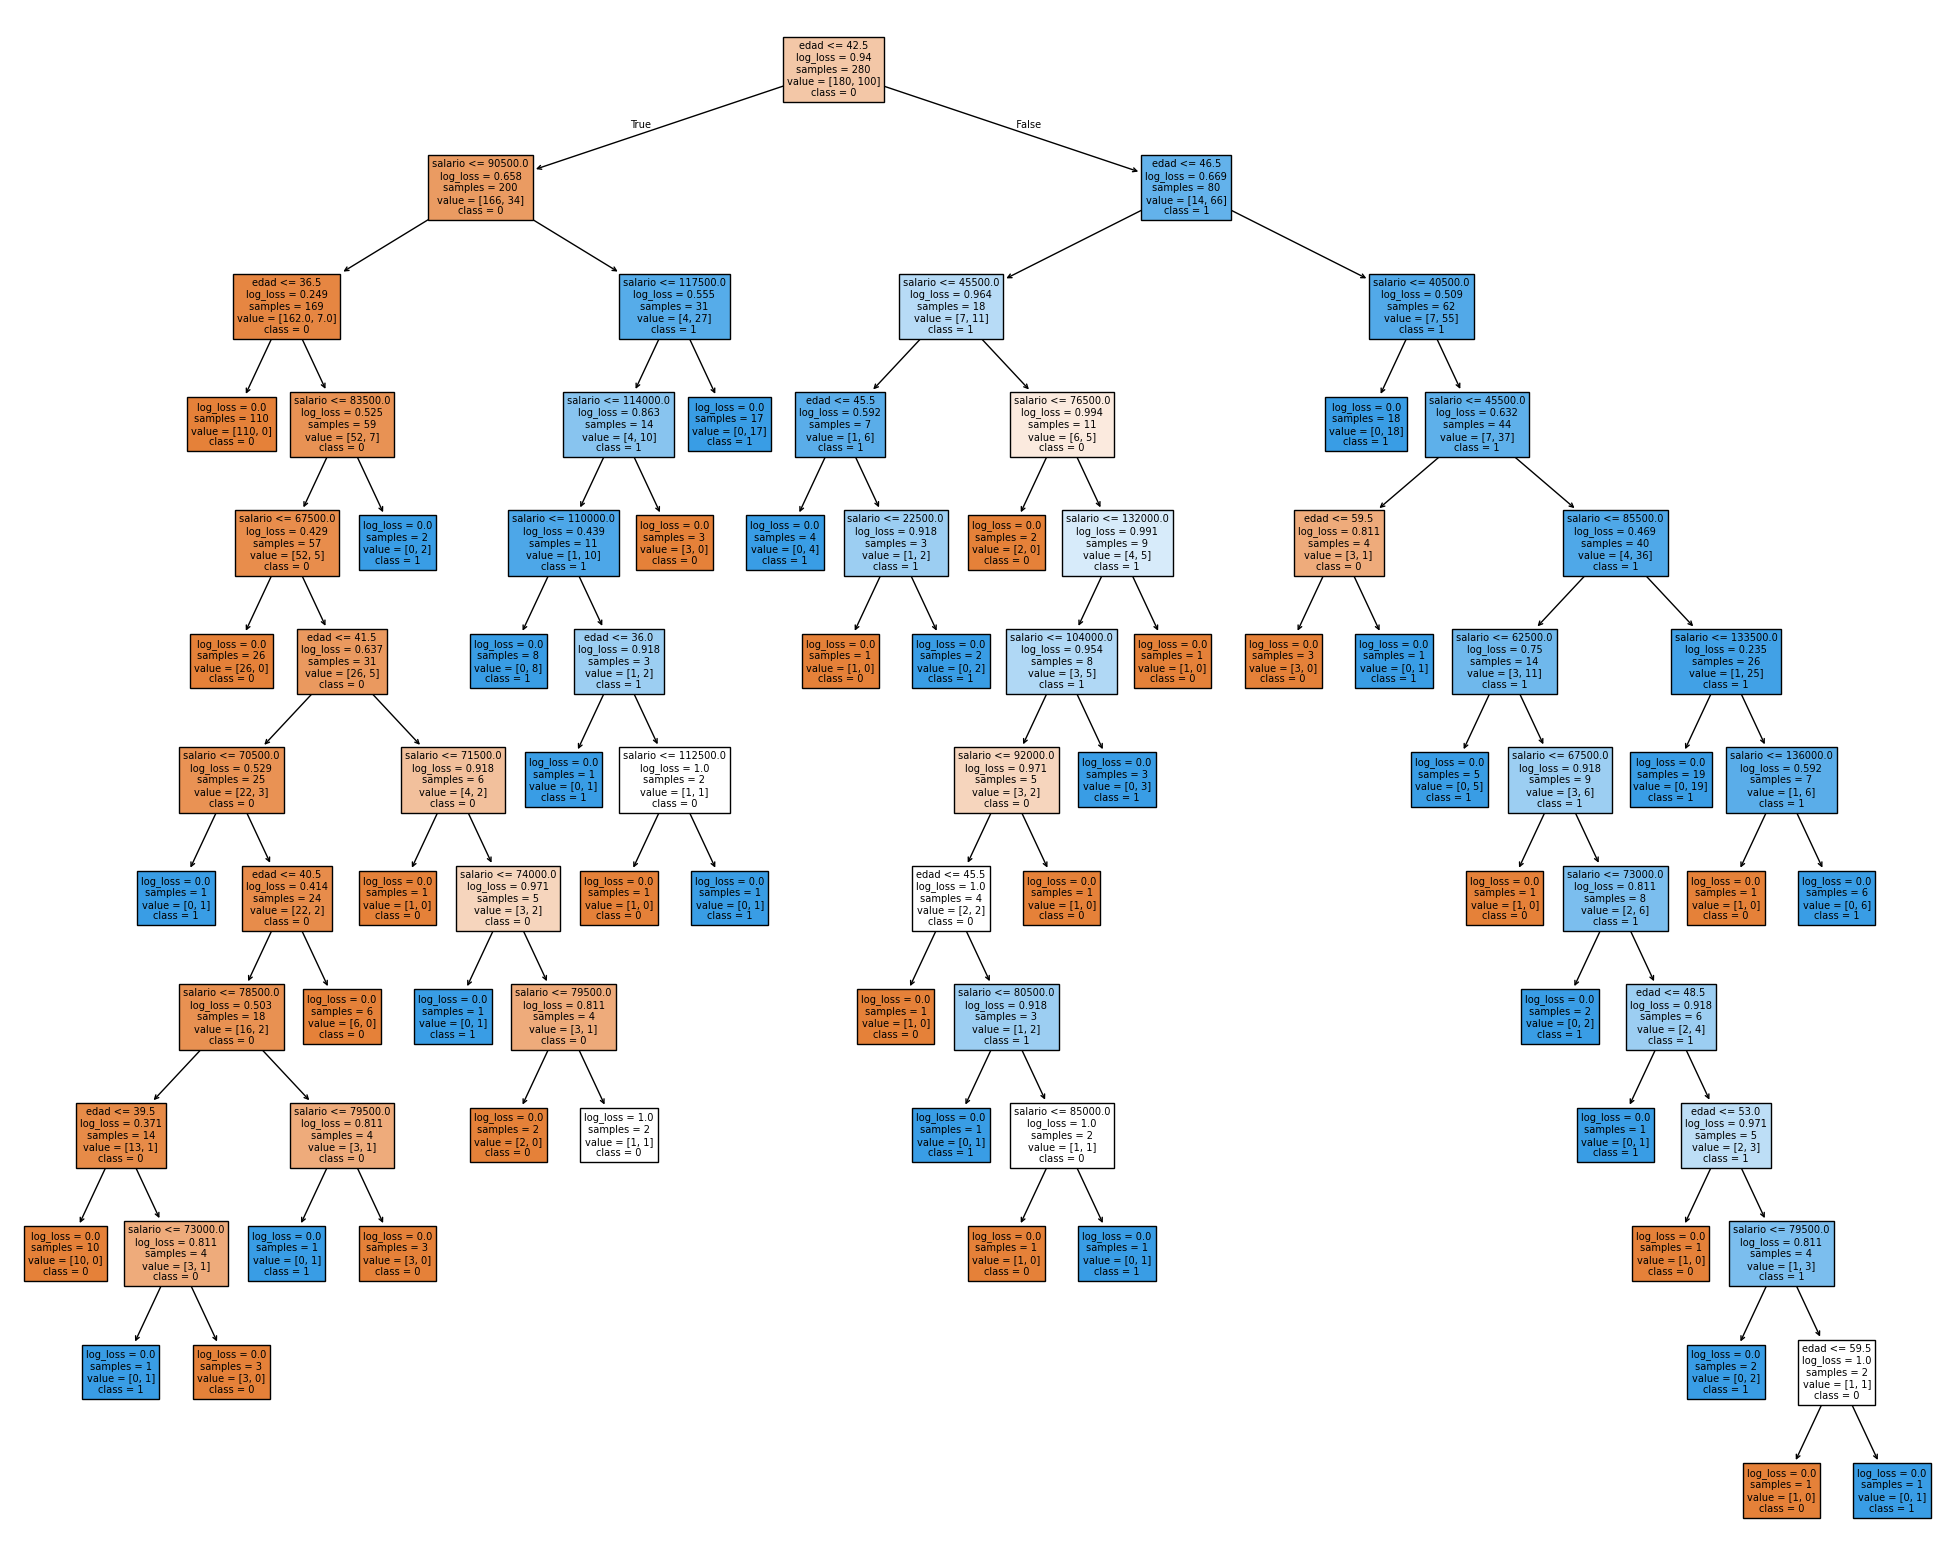

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


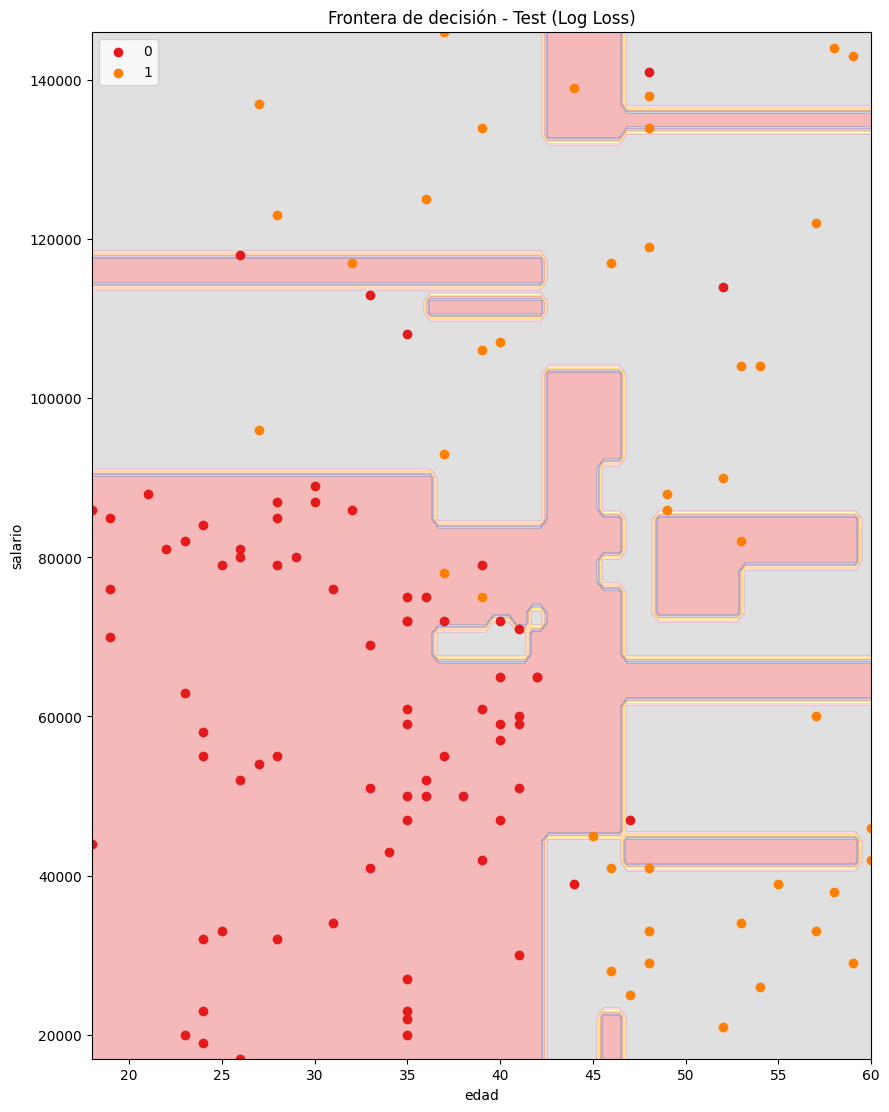

In [5]:
clf_3 = DecisionTreeClassifier(criterion="log_loss", random_state=semilla)
clf_3.fit(X_train, y_train)

print("Train Accuracy:", accuracy_score(y_train, clf_3.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, clf_3.predict(X_test)))
print(
    "\nReporte de clasificación:\n",
    classification_report(y_test, clf_2.predict(X_test)),
)

# Árbol
plt.figure(figsize=(25, 20))
plot_tree(
    clf_3,
    feature_names=X.columns,
    class_names=[str(c) for c in clf_3.classes_],
    filled=True,
)
plt.show()

# Frontera de decisión
plt.figure(figsize=(9, 11))
frontera_decision_tree(clf_3, X_test, y_test)
plt.title("Frontera de decisión - Test (Log Loss)")
plt.show()

- ¿Cambia la estructura del árbol?<br>
Respecto al apartado 'b/c', la estructura del árbol sí cambia. Respecto al apartado 'd', los árboles son iguales.

- ¿Cambian las fronteras?<br>
Por lo que yo veo, no cambian.

- Los valores del accuracy sugiere cambios en overfitting/underfitting<br>
Ocurre lo mismo que en el apartado 'd', por lo que la respuesta sería la misma.

## ENTREGA 4:
### a) Completa los apartados entregando código, resultados de ejecución y respuestas a las preguntas.
Se encuentra arriba.